# Phase 1 — Exploratory Data Analysis
## Ambrish Loganathan
## 23BDS0074

Tasks:
1. Loading the dataset
2. Basic statistical analysis
3. Handling missing data
4. Data cleaning
5. Data transformation
6. Univariate analysis (3+ visualizations)
7. Bivariate analysis (3+ visualizations)
8. Multivariate analysis (3+ visualizations)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)


## 1. Loading the Dataset

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/salemprakash/EDA/refs/heads/main/Data/diabetes.csv")
print("Shape:", df.shape)
df.head()


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148,72,35,0,33.6,0.627,50,1
1,1.0,85,66,29,0,26.6,0.351,31,0
2,8.0,183,64,0,0,23.3,0.672,32,1
3,1.0,89,66,23,94,28.1,0.167,21,0
4,0.0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               767 non-null    float64
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  767 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 54.1+ KB


## 2. Basic Statistical Analysis

In [4]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,767.000000,768.000000,768.000000,768.000000,768.000000,768.000000,767.000000,768.000000
mean,3.850065,120.894531,69.105469,20.536458,79.799479,31.992578,0.471995,33.240885
std,3.368910,31.972618,19.355807,15.952218,115.244002,7.884160,0.331529,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243500,24.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.371000,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626500,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [5]:
df.groupby("Outcome").mean(numeric_only=True)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.313883,109.977912,68.172691,19.686747,69.068273,30.299799,0.429885,31.208835
1,4.857678,141.411985,71.089888,22.247191,100.711610,35.161798,0.550749,37.086142
?,3.000000,107.000000,47.333333,9.333333,0.000000,30.933333,0.439000,28.333333


In [6]:
print("Skewness:\n", df.skew(numeric_only=True))
print("\nKurtosis:\n", df.kurt(numeric_only=True))


Skewness:
 Pregnancies                 0.900862
Glucose                     0.173754
BloodPressure              -1.843608
SkinThickness               0.109372
Insulin                     2.272251
BMI                        -0.428982
DiabetesPedigreeFunction    1.917900
Age                         1.129597
dtype: float64

Kurtosis:
 Pregnancies                 0.158261
Glucose                     0.640780
BloodPressure               5.180157
SkinThickness              -0.520072
Insulin                     7.214260
BMI                         3.290443
DiabetesPedigreeFunction    5.582729
Age                         0.643159
dtype: float64


## 3. Handling Missing Data

In this dataset, biologically impossible zero values in certain columns
(`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) actually
represent missing data rather than true zeros. We first convert these to `NaN`
so they can be handled properly.

In [7]:
df.isnull().sum()


,0
Pregnancies,1
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,1
Age,0
Outcome,0


In [8]:
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df_clean = df.copy()
df_clean[zero_as_missing_cols] = df_clean[zero_as_missing_cols].replace(0, np.nan)

print("Missing values after converting zeros to NaN:")
df_clean.isnull().sum()


Missing values after converting zeros to NaN:


,0
Pregnancies,1
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,1
Age,0
Outcome,0


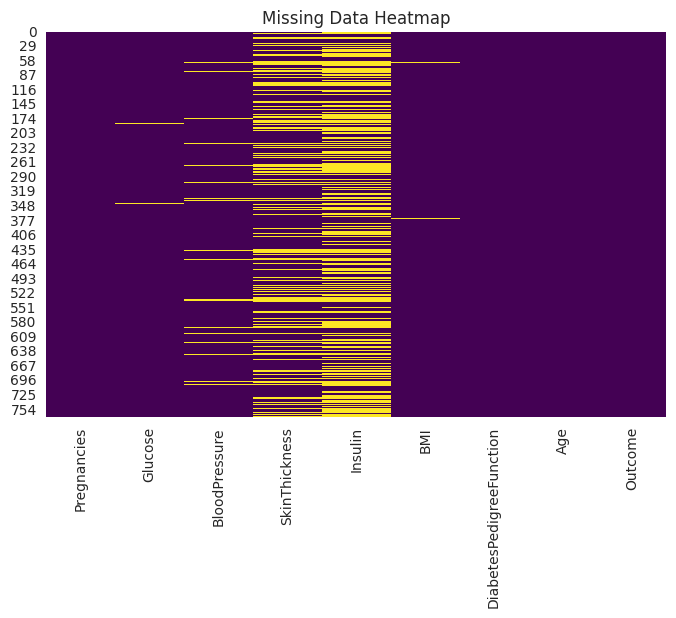

In [9]:
plt.figure(figsize=(8, 5))
sns.heatmap(df_clean.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()


In [10]:
for col in zero_as_missing_cols:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Missing values after imputation:")
df_clean.isnull().sum()


Missing values after imputation:


,0
Pregnancies,1
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,3
BMI,0
DiabetesPedigreeFunction,1
Age,0
Outcome,0


## 4. Data Cleaning

In [11]:
print("Duplicate rows:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()


print("\nData types:\n", df_clean.dtypes)


Duplicate rows: 0

Data types:
 Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                      object
dtype: object


In [12]:
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

numeric_cols = df_clean.select_dtypes(include=np.number).columns
outlier_counts = {col: count_outliers_iqr(df_clean[col]) for col in numeric_cols}
outlier_counts


{'Pregnancies': np.int64(4),
 'Glucose': np.int64(0),
 'BloodPressure': np.int64(14),
 'SkinThickness': np.int64(87),
 'Insulin': np.int64(51),
 'BMI': np.int64(8),
 'DiabetesPedigreeFunction': np.int64(29),
 'Age': np.int64(9)}

In [13]:
df_capped = df_clean.copy()
for col in numeric_cols:
    if col == "Outcome":
        continue
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

df_capped.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,767.000000,768.000000,768.000000,768.000000,765.000000,768.000000,767.000000,768.000000
mean,3.842243,121.677083,72.356120,28.844401,133.118301,32.372786,0.459053,33.199870
std,3.343462,30.464161,11.706669,7.558132,58.202245,6.672767,0.285867,11.628404
min,0.000000,44.000000,40.000000,14.500000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243500,24.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.371000,29.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626500,41.000000
max,13.500000,199.000000,104.000000,42.500000,270.000000,50.250000,1.201000,66.500000


## 5. Data Transformation

We create a scaled version of the features (useful for downstream modeling)
and bin `Age` and `BMI` into meaningful categories.

In [14]:
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in df_capped.columns if c != "Outcome"]
scaler = StandardScaler()

df_scaled = df_capped.copy()
df_scaled[feature_cols] = scaler.fit_transform(df_capped[feature_cols])
df_scaled.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.645787,0.864625,-0.030440,0.814965,0.625500,0.184034,0.587882,1.445691,1
1,-0.850644,-1.204727,-0.543302,0.020600,-0.526412,-0.865690,-0.378232,-0.189304,0
2,1.244360,2.014265,-0.714257,0.417782,0.625500,-1.360560,0.745401,-0.103252,1
3,-0.850644,-1.073339,-0.543302,-0.773764,-0.672550,-0.640749,-1.022308,-1.049828,0
4,-1.149931,0.503310,-2.765706,0.814965,0.599711,1.608659,2.597119,-0.017199,1


In [15]:
df_capped["AgeGroup"] = pd.cut(
    df_capped["Age"], bins=[20, 30, 40, 50, 60, 100],
    labels=["21-30", "31-40", "41-50", "51-60", "60+"]
)

df_capped["BMICategory"] = pd.cut(
    df_capped["BMI"], bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

df_capped[["Age", "AgeGroup", "BMI", "BMICategory"]].head()


,Age,AgeGroup,BMI,BMICategory
0,50.0,41-50,33.6,Obese
1,31.0,31-40,26.6,Overweight
2,32.0,31-40,23.3,Normal
3,21.0,21-30,28.1,Overweight
4,33.0,31-40,43.1,Obese


## 6. Univariate Analysis (3+ Visualizations)

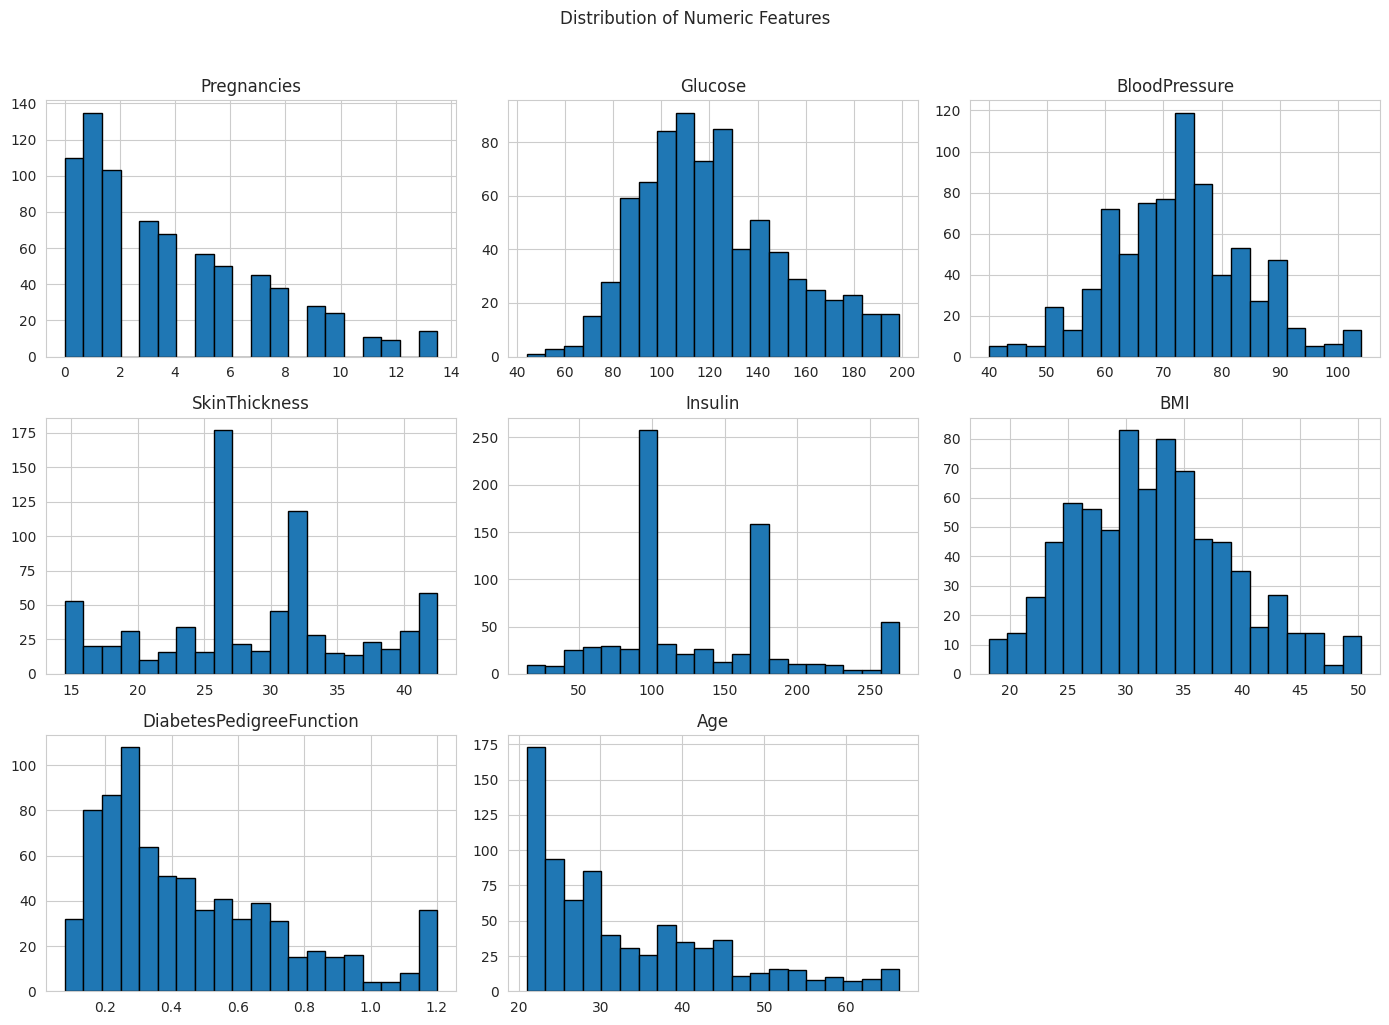

In [16]:
df_capped[numeric_cols].hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Distribution of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()


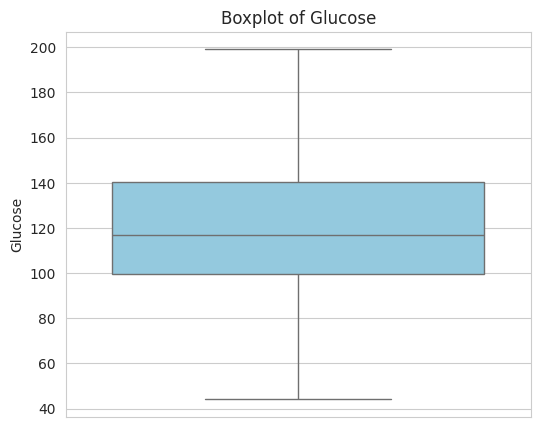

In [17]:
plt.figure(figsize=(6, 5))
sns.boxplot(y=df_capped["Glucose"], color="skyblue")
plt.title("Boxplot of Glucose")
plt.show()


/tmp/ipykernel_467/805478995.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outcome", data=df_capped, palette="Set2")


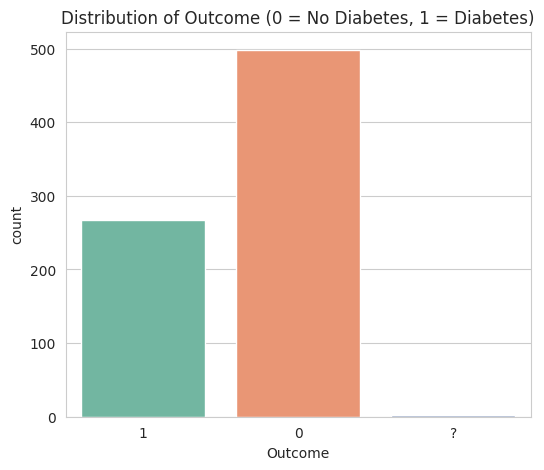

In [18]:
plt.figure(figsize=(6, 5))
sns.countplot(x="Outcome", data=df_capped, palette="Set2")
plt.title("Distribution of Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.show()


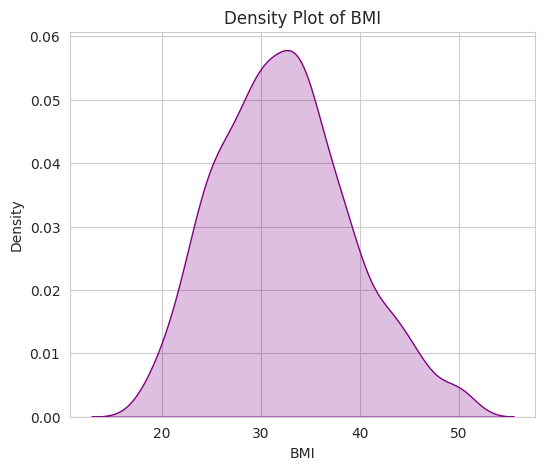

In [19]:
plt.figure(figsize=(6, 5))
sns.kdeplot(df_capped["BMI"], fill=True, color="purple")
plt.title("Density Plot of BMI")
plt.show()


## 7. Bivariate Analysis (3+ Visualizations)

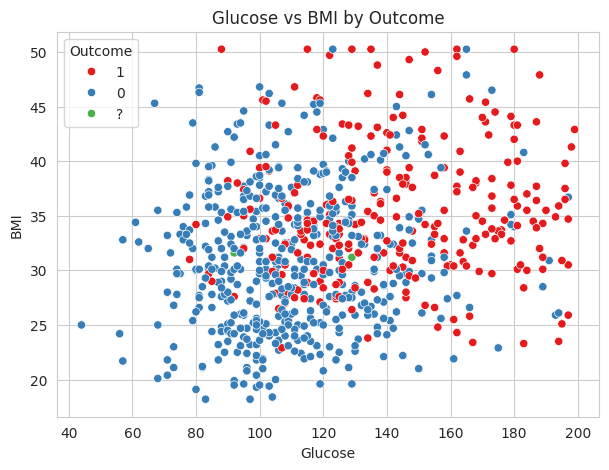

In [20]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="Glucose", y="BMI", hue="Outcome", data=df_capped, palette="Set1")
plt.title("Glucose vs BMI by Outcome")
plt.show()


/tmp/ipykernel_467/3872956204.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y="Age", data=df_capped, palette="Set3")


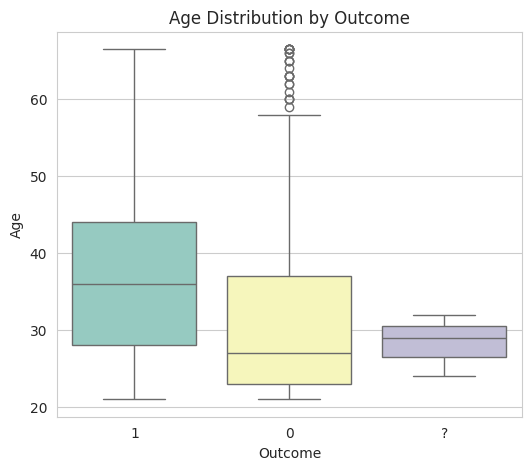

In [21]:
plt.figure(figsize=(6, 5))
sns.boxplot(x="Outcome", y="Age", data=df_capped, palette="Set3")
plt.title("Age Distribution by Outcome")
plt.show()


/tmp/ipykernel_467/2268327151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AgeGroup", y="Glucose", data=df_capped, palette="viridis")


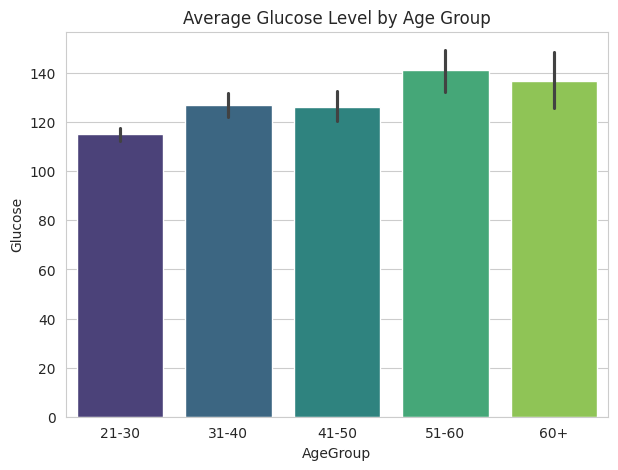

In [22]:
plt.figure(figsize=(7, 5))
sns.barplot(x="AgeGroup", y="Glucose", data=df_capped, palette="viridis")
plt.title("Average Glucose Level by Age Group")
plt.show()


/tmp/ipykernel_467/318778008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Outcome", y="Insulin", data=df_capped, palette="muted")


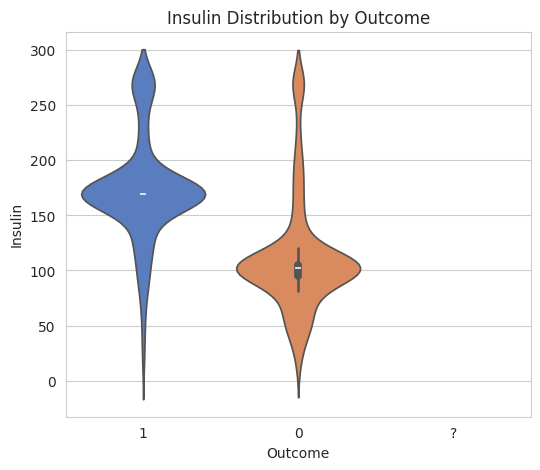

In [23]:
plt.figure(figsize=(6, 5))
sns.violinplot(x="Outcome", y="Insulin", data=df_capped, palette="muted")
plt.title("Insulin Distribution by Outcome")
plt.show()


## 8. Multivariate Analysis (3+ Visualizations)

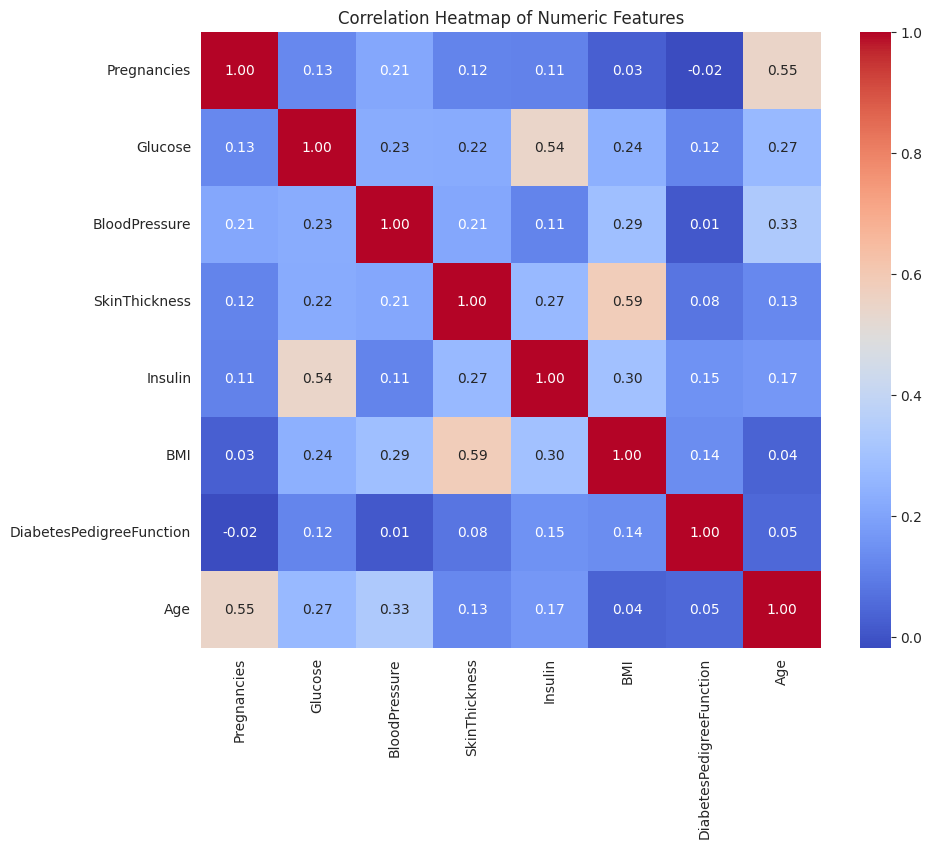

In [24]:
plt.figure(figsize=(10, 8))
corr = df_capped[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


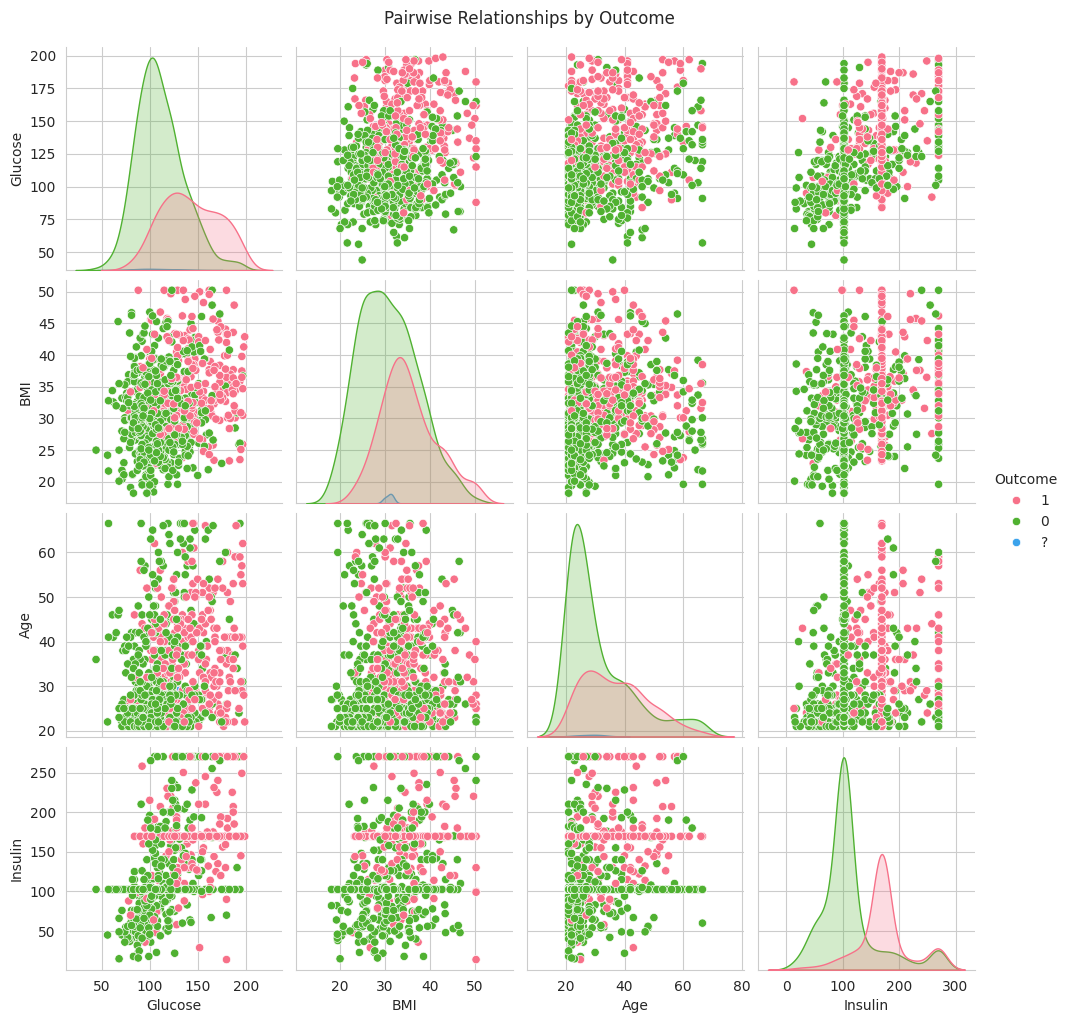

In [25]:
sns.pairplot(
    df_capped,
    vars=["Glucose", "BMI", "Age", "Insulin"],
    hue="Outcome",
    palette="husl",
    diag_kind="kde"
)
plt.suptitle("Pairwise Relationships by Outcome", y=1.02)
plt.show()


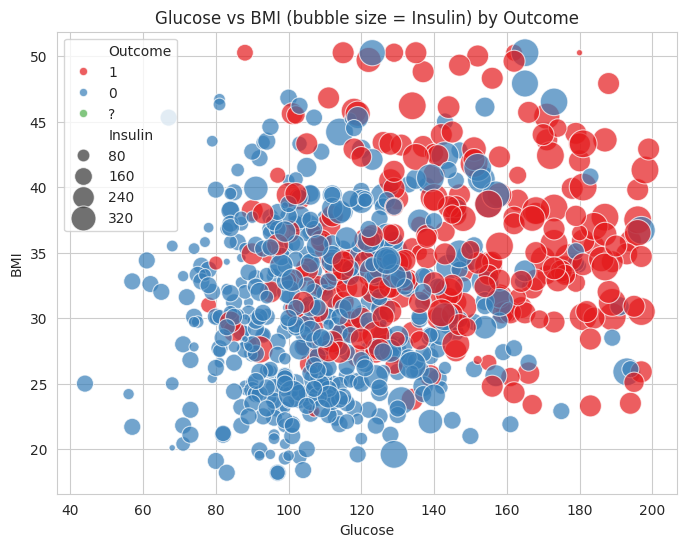

In [26]:
plt.figure(figsize=(8, 6))
sizes = (df_capped["Insulin"] - df_capped["Insulin"].min() + 10) * 1.5
sns.scatterplot(
    x="Glucose", y="BMI", size=sizes, hue="Outcome",
    data=df_capped, sizes=(20, 400), palette="Set1", alpha=0.7, legend="brief"
)
plt.title("Glucose vs BMI (bubble size = Insulin) by Outcome")
plt.show()


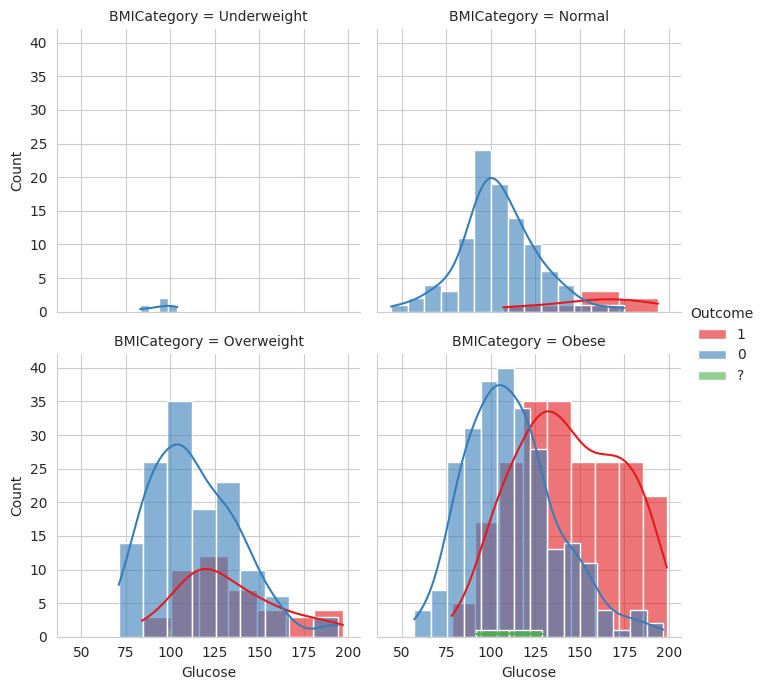

In [27]:
g = sns.FacetGrid(df_capped, col="BMICategory", hue="Outcome", palette="Set1", col_wrap=2, height=3.5)
g.map(sns.histplot, "Glucose", kde=True, alpha=0.6)
g.add_legend()
plt.show()


# Phase 2 — Statistical Analysis, KNN Classification and Hierarchical Clustering

Tasks 2–14 (summary statistics through the pairs plot), plus KNN classification and
hierarchical clustering, all in Python (`pandas`, `numpy`, `scipy.stats`, `seaborn`,
`scikit-learn`), using `df_p2` from the setup cell above.

In [28]:
# Prepare the data for Phase 2.
# "Outcome" contains a few "?" entries in this file, and Pregnancies / DiabetesPedigreeFunction
# have one NaN each; those few rows are dropped so every analysis below is on complete data.
df_p2 = df_clean.copy()
df_p2["Outcome"] = pd.to_numeric(df_p2["Outcome"], errors="coerce")
print("Rows dropped:", df_p2.isnull().any(axis=1).sum())
df_p2 = df_p2.dropna().reset_index(drop=True)
df_p2["Outcome"] = df_p2["Outcome"].astype(int)

df_p2["AgeGroup"] = pd.cut(
    df_p2["Age"], bins=[20, 30, 40, 50, 60, 100],
    labels=["21-30", "31-40", "41-50", "51-60", "60+"]
)
df_p2["BMICategory"] = pd.cut(
    df_p2["BMI"], bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

print("Shape for Phase 2:", df_p2.shape)

Rows dropped: 5
Shape for Phase 2: (763, 11)


In [29]:
from scipy import stats as sps

df2 = df_p2.copy()
df2["Outcome"] = df2["Outcome"].map({0: "No Diabetes", 1: "Diabetes"})
num_vars_py = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
               "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
df2.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeGroup,BMICategory
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50,Diabetes,41-50,Obese
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31,No Diabetes,31-40,Overweight
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32,Diabetes,31-40,Normal
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,No Diabetes,21-30,Overweight
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33,Diabetes,31-40,Obese


## 2. Summary Statistics

In [30]:
def summary_stats_py(x):
    return pd.Series({
        "Mean": x.mean(), "Median": x.median(), "Minimum": x.min(), "Maximum": x.max(),
        "Range": x.max() - x.min(), "Variance": x.var(), "Std_Dev": x.std(),
        "IQR": x.quantile(0.75) - x.quantile(0.25),
        "Skewness": sps.skew(x), "Kurtosis": sps.kurtosis(x)   # excess kurtosis (fisher=True), matches e1071
    })

glucose_stats_py = summary_stats_py(df2["Glucose"])
print(glucose_stats_py.round(4))

Mean        121.8126
Median      117.0000
Minimum      44.0000
Maximum     199.0000
Range       155.0000
Variance    929.9793
Std_Dev      30.4956
IQR          41.0000
Skewness      0.5239
Kurtosis     -0.2809
dtype: float64


## 3. Store the Statistics in a Single Data Frame

In [31]:
stats_df_py = df2[num_vars_py].apply(summary_stats_py).T
stats_df_py.round(4)

,Mean,Median,Minimum,Maximum,Range,Variance,Std_Dev,IQR,Skewness,Kurtosis
Pregnancies,3.8585,3.00,0.000,17.00,17.000,11.3526,3.3694,5.000,0.8990,0.1496
Glucose,121.8126,117.00,44.000,199.00,155.000,929.9793,30.4956,41.000,0.5239,-0.2809
BloodPressure,72.4122,72.00,24.000,122.00,98.000,147.0671,12.1271,16.000,0.1370,1.0655
SkinThickness,29.0917,28.00,7.000,99.00,92.000,79.5139,8.9171,7.000,0.8134,4.9841
Insulin,141.7962,102.50,14.000,846.00,832.000,7976.6366,89.3120,67.000,3.0188,13.6999
BMI,32.4356,32.20,18.200,67.10,48.900,47.5498,6.8956,9.100,0.6034,0.8907
DiabetesPedigreeFunction,0.4720,0.37,0.078,2.42,2.342,0.1103,0.3321,0.383,1.9156,5.5263
Age,33.2857,29.00,21.000,81.00,60.000,138.8159,11.7820,17.000,1.1194,0.6090


## 4. Frequency Distributions for a Categorical Variable

Variable: `BMICategory`.

             Frequency  Relative_Frequency  Percent
BMICategory                                        
Underweight          4              0.0052     0.52
Normal             108              0.1415    14.15
Overweight         178              0.2333    23.33
Obese              473              0.6199    61.99


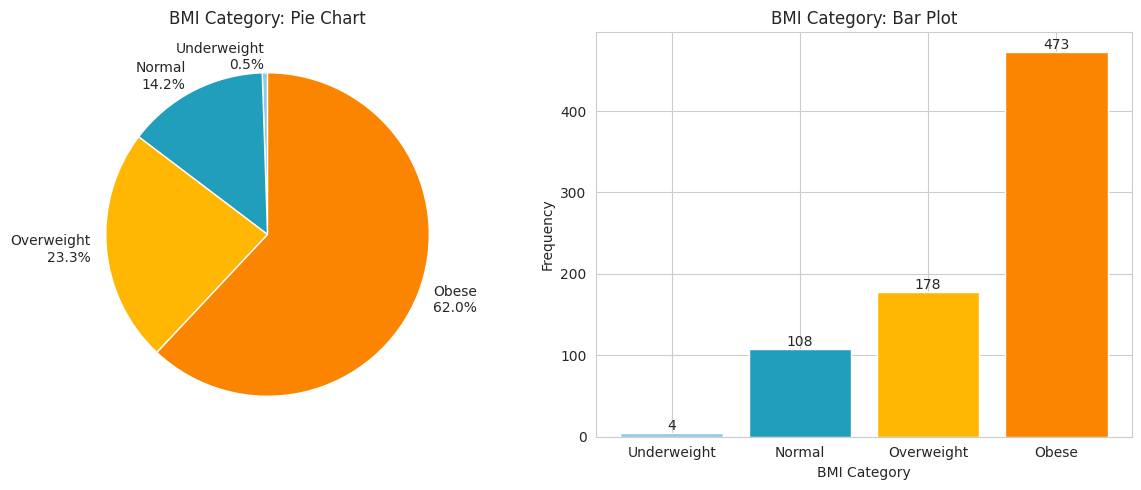

In [32]:
freq_py = df2["BMICategory"].value_counts().sort_index()
rel_freq_py = df2["BMICategory"].value_counts(normalize=True).sort_index()

freq_table_py = pd.DataFrame({
    "Frequency": freq_py,
    "Relative_Frequency": rel_freq_py.round(4),
    "Percent": (rel_freq_py * 100).round(2)
})
print(freq_table_py)

colors = ["#8ecae6", "#219ebc", "#ffb703", "#fb8500"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(freq_py, labels=[f"{c}\n{p:.1f}%" for c, p in zip(freq_py.index, rel_freq_py * 100)],
            colors=colors, startangle=90)
axes[0].set_title("BMI Category: Pie Chart")

bars = axes[1].bar(freq_py.index.astype(str), freq_py.values, color=colors)
axes[1].bar_label(bars)
axes[1].set_title("BMI Category: Bar Plot")
axes[1].set_xlabel("BMI Category"); axes[1].set_ylabel("Frequency")
plt.tight_layout(); plt.show()

## 5. Binned Frequency Distribution, Histogram and Box Plot

Variable: `BMI` (has visible outliers, unlike `Glucose`).

                              Frequency  Relative_Frequency  \
BMI                                                           
(18.198999999999998, 22.645]         47              0.0616   
(22.645, 27.091]                    127              0.1664   
(27.091, 31.536]                    180              0.2359   
(31.536, 35.982]                    202              0.2647   
(35.982, 40.427]                    113              0.1481   
(40.427, 44.873]                     58              0.0760   
(44.873, 49.318]                     25              0.0328   
(49.318, 53.764]                      7              0.0092   
(53.764, 58.209]                      2              0.0026   
(58.209, 62.655]                      1              0.0013   
(62.655, 67.1]                        1              0.0013   

                              Cumulative_Frequency  
BMI                                                 
(18.198999999999998, 22.645]                    47  
(22.645, 27.091]     

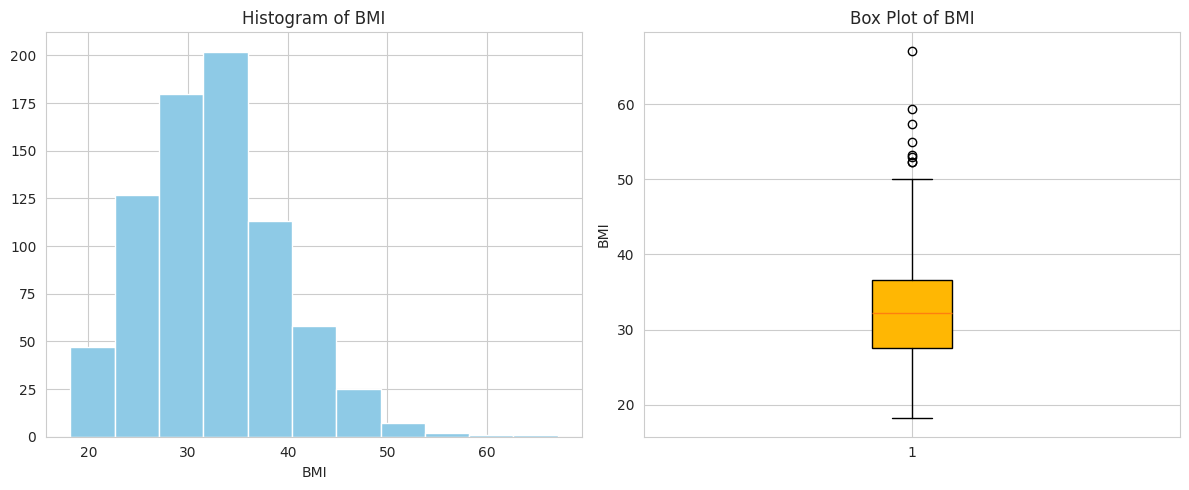


Outliers (beyond 1.5 x IQR): 8
[52.3, 52.3, 52.9, 53.2, 55.0, 57.3, 59.4, 67.1]


In [33]:
x_py = df2["BMI"]
n_bins = int(np.ceil(np.log2(len(x_py)) + 1))          # Sturges' rule
bin_edges = np.histogram_bin_edges(x_py, bins=n_bins)
binned = pd.cut(x_py, bins=bin_edges, include_lowest=True)

f_py = binned.value_counts().sort_index()
bin_table_py = pd.DataFrame({
    "Frequency": f_py,
    "Relative_Frequency": (f_py / f_py.sum()).round(4),
    "Cumulative_Frequency": f_py.cumsum()
})
print(bin_table_py)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(x_py, bins=bin_edges, color="#8ecae6", edgecolor="white")
axes[0].set_title("Histogram of BMI"); axes[0].set_xlabel("BMI")

axes[1].boxplot(x_py, patch_artist=True, boxprops=dict(facecolor="#ffb703"))
axes[1].set_title("Box Plot of BMI"); axes[1].set_ylabel("BMI")
plt.tight_layout(); plt.show()

Q1, Q3 = x_py.quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers_py = x_py[(x_py < Q1 - 1.5 * IQR) | (x_py > Q3 + 1.5 * IQR)]
print(f"\nOutliers (beyond 1.5 x IQR): {len(outliers_py)}")
print(sorted(outliers_py.tolist()))

## 6. Contingency Table with Row and Column Percentages

Variables: `BMICategory` and `Outcome`.

In [34]:
ct_py = pd.crosstab(df2["BMICategory"], df2["Outcome"])
print("Contingency table (with totals)")
print(ct_py.assign(Total=ct_py.sum(axis=1)).pipe(lambda d: pd.concat([d, d.sum(axis=0).rename("Total").to_frame().T])))

print("\nRow percentages (each BMI category sums to 100)")
print((pd.crosstab(df2["BMICategory"], df2["Outcome"], normalize="index") * 100).round(2))

print("\nColumn percentages (each Outcome sums to 100)")
print((pd.crosstab(df2["BMICategory"], df2["Outcome"], normalize="columns") * 100).round(2))

Contingency table (with totals)
Outcome      Diabetes  No Diabetes  Total
Underweight         0            4      4
Normal              7          101    108
Overweight         43          135    178
Obese             217          256    473
Total             267          496    763

Row percentages (each BMI category sums to 100)
Outcome      Diabetes  No Diabetes
BMICategory                       
Underweight      0.00       100.00
Normal           6.48        93.52
Overweight      24.16        75.84
Obese           45.88        54.12

Column percentages (each Outcome sums to 100)
Outcome      Diabetes  No Diabetes
BMICategory                       
Underweight      0.00         0.81
Normal           2.62        20.36
Overweight      16.10        27.22
Obese           81.27        51.61


## 7. Stacked and Grouped Bar Plots

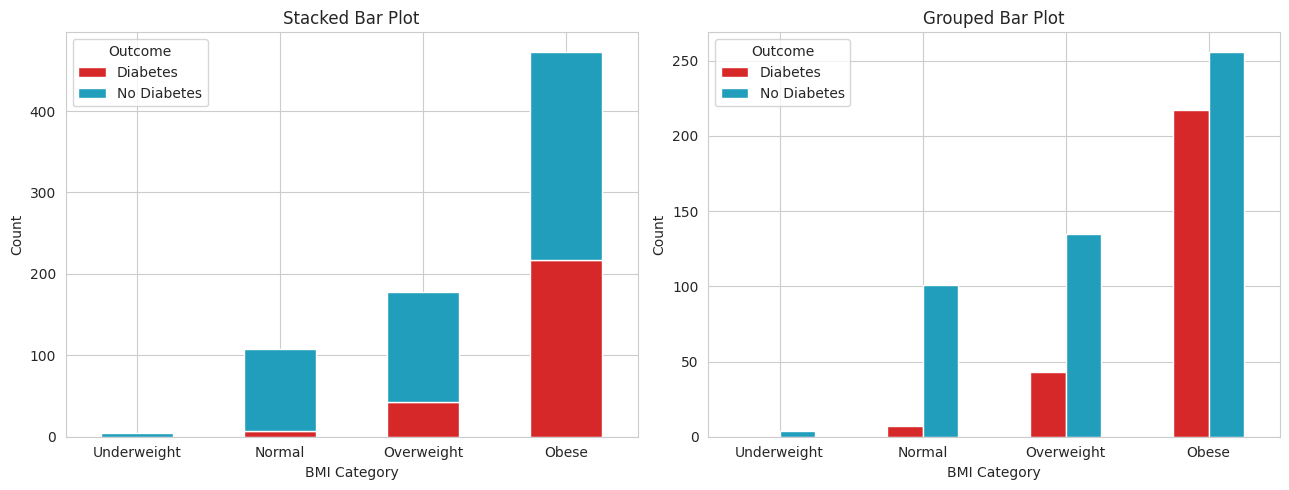

In [35]:
out_colors = {"No Diabetes": "#219ebc", "Diabetes": "#d62828"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct_py.plot(kind="bar", stacked=True, ax=axes[0],
           color=[out_colors[c] for c in ct_py.columns])
axes[0].set_title("Stacked Bar Plot"); axes[0].set_xlabel("BMI Category"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

ct_py.plot(kind="bar", stacked=False, ax=axes[1],
           color=[out_colors[c] for c in ct_py.columns])
axes[1].set_title("Grouped Bar Plot"); axes[1].set_xlabel("BMI Category"); axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 8. Grouped Summary with groupby().agg()

Categorical: `Outcome`, numerical: `Glucose`.

In [36]:
agg_py = df2.groupby("Outcome")["Glucose"].agg(Mean="mean", Median="median", SD="std").round(3)
agg_py

,Mean,Median,SD
Outcome,,,
Diabetes,142.461,140.0,29.430
No Diabetes,110.698,107.0,24.747


## 9. Side-by-Side Box Plots and Violin Plot

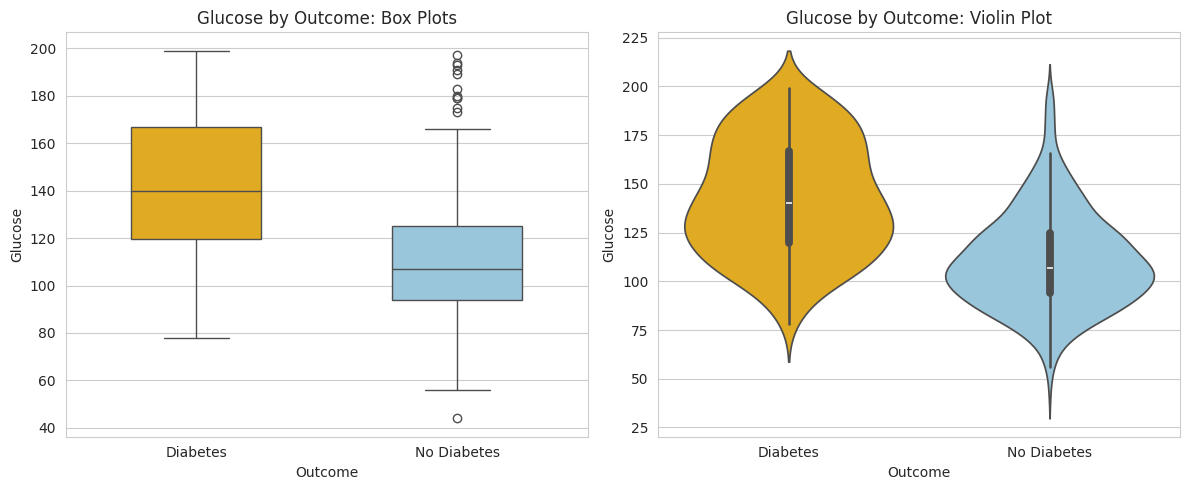

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette = {"No Diabetes": "#8ecae6", "Diabetes": "#ffb703"}

sns.boxplot(x="Outcome", y="Glucose", hue="Outcome", data=df2, palette=palette, legend=False, ax=axes[0], width=0.5)
axes[0].set_title("Glucose by Outcome: Box Plots")

sns.violinplot(x="Outcome", y="Glucose", hue="Outcome", data=df2, palette=palette, legend=False, ax=axes[1])
axes[1].set_title("Glucose by Outcome: Violin Plot")
plt.tight_layout(); plt.show()

## 10. Pearson and Spearman Correlation with Scatter Plot

Variables: `BMI` and `Glucose`.

     Method  Correlation
0   Pearson       0.2373
1  Spearman       0.2343


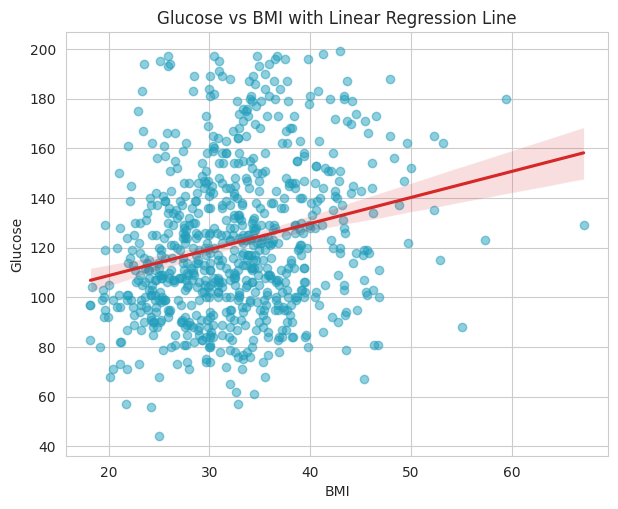

In [38]:
pearson_r_py, _ = sps.pearsonr(df2["BMI"], df2["Glucose"])
spearman_r_py, _ = sps.spearmanr(df2["BMI"], df2["Glucose"])
print(pd.DataFrame({"Method": ["Pearson", "Spearman"],
                    "Correlation": [round(pearson_r_py, 4), round(spearman_r_py, 4)]}))

plt.figure(figsize=(7, 5.5))
sns.regplot(x="BMI", y="Glucose", data=df2, scatter_kws={"alpha": 0.5, "color": "#219ebc"},
            line_kws={"color": "#d62828"})
plt.title("Glucose vs BMI with Linear Regression Line")
plt.show()

## 11. Two Categorical Features and One Numerical Feature

Categorical: `AgeGroup` and `Outcome`, numerical: `Glucose`. Error bars show mean ± 1 standard deviation.

  AgeGroup      Outcome     Mean      SD    N
0    21-30     Diabetes  140.322  29.765   90
1    21-30  No Diabetes  108.043  21.599  323
2    31-40     Diabetes  141.387  28.633   75
3    31-40  No Diabetes  114.148  29.073   81
4    41-50     Diabetes  140.000  28.507   64
5    41-50  No Diabetes  108.000  28.855   49
6    51-60     Diabetes  153.452  30.619   31
7    51-60  No Diabetes  124.565  24.222   23
8      60+     Diabetes  155.286  30.982    7
9      60+  No Diabetes  130.250  29.714   20


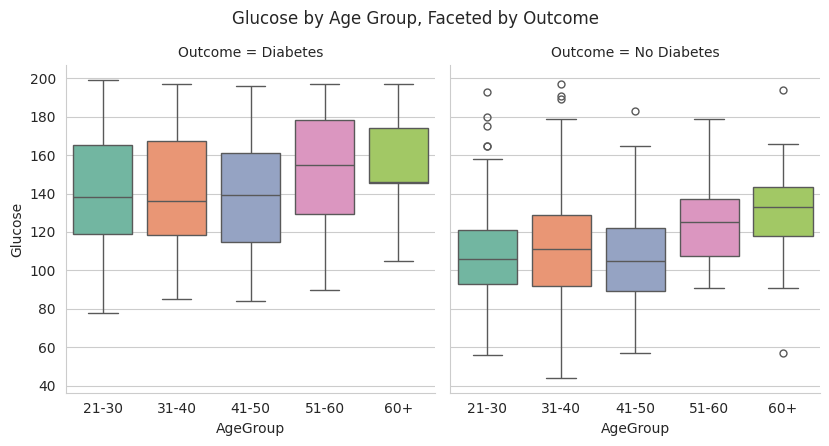

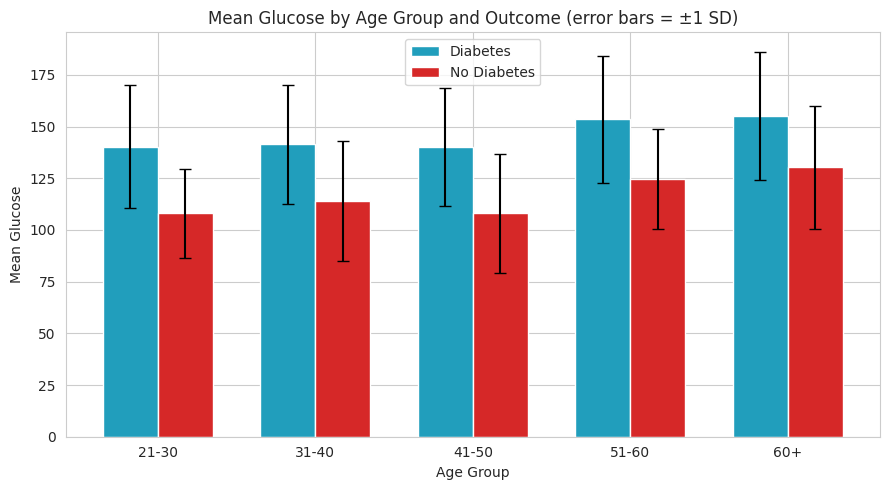

In [39]:
agg2_py = df2.groupby(["AgeGroup", "Outcome"], observed=True)["Glucose"].agg(Mean="mean", SD="std", N="count").round(3).reset_index()
print(agg2_py)

g = sns.catplot(x="AgeGroup", y="Glucose", hue="AgeGroup", col="Outcome", data=df2,
                 kind="box", palette="Set2", legend=False, height=4.2, aspect=1)
g.fig.suptitle("Glucose by Age Group, Faceted by Outcome", y=1.05)
plt.show()

pivot = agg2_py.pivot(index="AgeGroup", columns="Outcome", values="Mean")
pivot_sd = agg2_py.pivot(index="AgeGroup", columns="Outcome", values="SD")
x_pos = np.arange(len(pivot.index)); width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
for k, (col, color) in enumerate(zip(pivot.columns, ["#219ebc", "#d62828"])):
    ax.bar(x_pos + (k - 0.5) * width, pivot[col], width, yerr=pivot_sd[col],
           capsize=4, label=col, color=color)
ax.set_xticks(x_pos); ax.set_xticklabels(pivot.index)
ax.set_xlabel("Age Group"); ax.set_ylabel("Mean Glucose")
ax.set_title("Mean Glucose by Age Group and Outcome (error bars = ±1 SD)")
ax.legend(); plt.tight_layout(); plt.show()

## 12. Scatter Plot by Category and Per-Category Correlation Matrices

Categorical: `Outcome`, numerical: `Age` and `Glucose`.

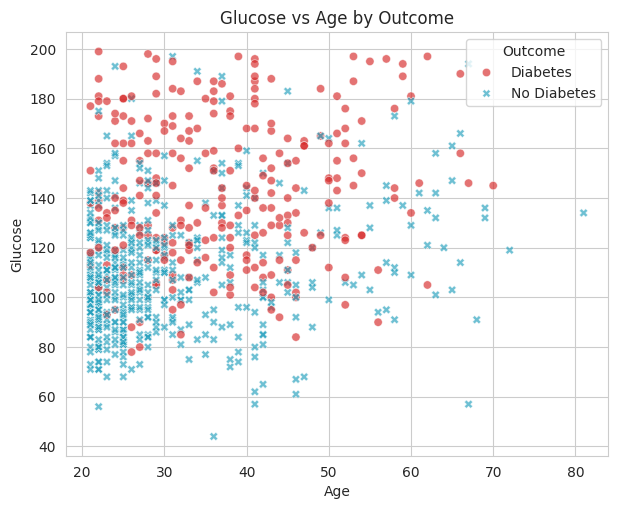


Diabetes
           Age  Glucose
Age      1.000    0.111
Glucose  0.111    1.000

No Diabetes
            Age  Glucose
Age      1.0000   0.2182
Glucose  0.2182   1.0000


In [40]:
plt.figure(figsize=(7, 5.5))
sns.scatterplot(x="Age", y="Glucose", hue="Outcome", style="Outcome",
                 data=df2, palette=out_colors, alpha=0.65)
plt.title("Glucose vs Age by Outcome")
plt.show()

for level, sub in df2.groupby("Outcome"):
    print(f"\n{level}")
    print(sub[["Age", "Glucose"]].corr().round(4))

## 13. Correlation Matrix Heatmap

All eight numerical features.

                          Pregnancies  Glucose  BloodPressure  SkinThickness  \
Pregnancies                      1.00     0.13           0.21           0.09   
Glucose                          0.13     1.00           0.22           0.23   
BloodPressure                    0.21     0.22           1.00           0.20   
SkinThickness                    0.09     0.23           0.20           1.00   
Insulin                          0.06     0.49           0.07           0.20   
BMI                              0.02     0.24           0.29           0.57   
DiabetesPedigreeFunction        -0.03     0.14          -0.00           0.11   
Age                              0.54     0.27           0.32           0.13   

                          Insulin   BMI  DiabetesPedigreeFunction   Age  
Pregnancies                  0.06  0.02                     -0.03  0.54  
Glucose                      0.49  0.24                      0.14  0.27  
BloodPressure                0.07  0.29                  

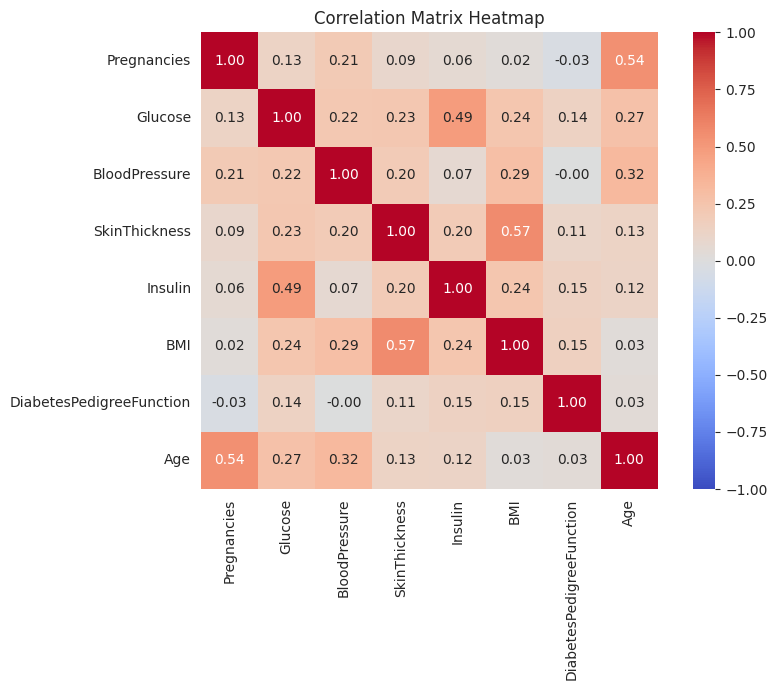

In [41]:
cm_py = df2[num_vars_py].corr()
print(cm_py.round(2))

plt.figure(figsize=(9, 7))
sns.heatmap(cm_py, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout(); plt.show()

## 14. Pairs Plot / Scatterplot Matrix

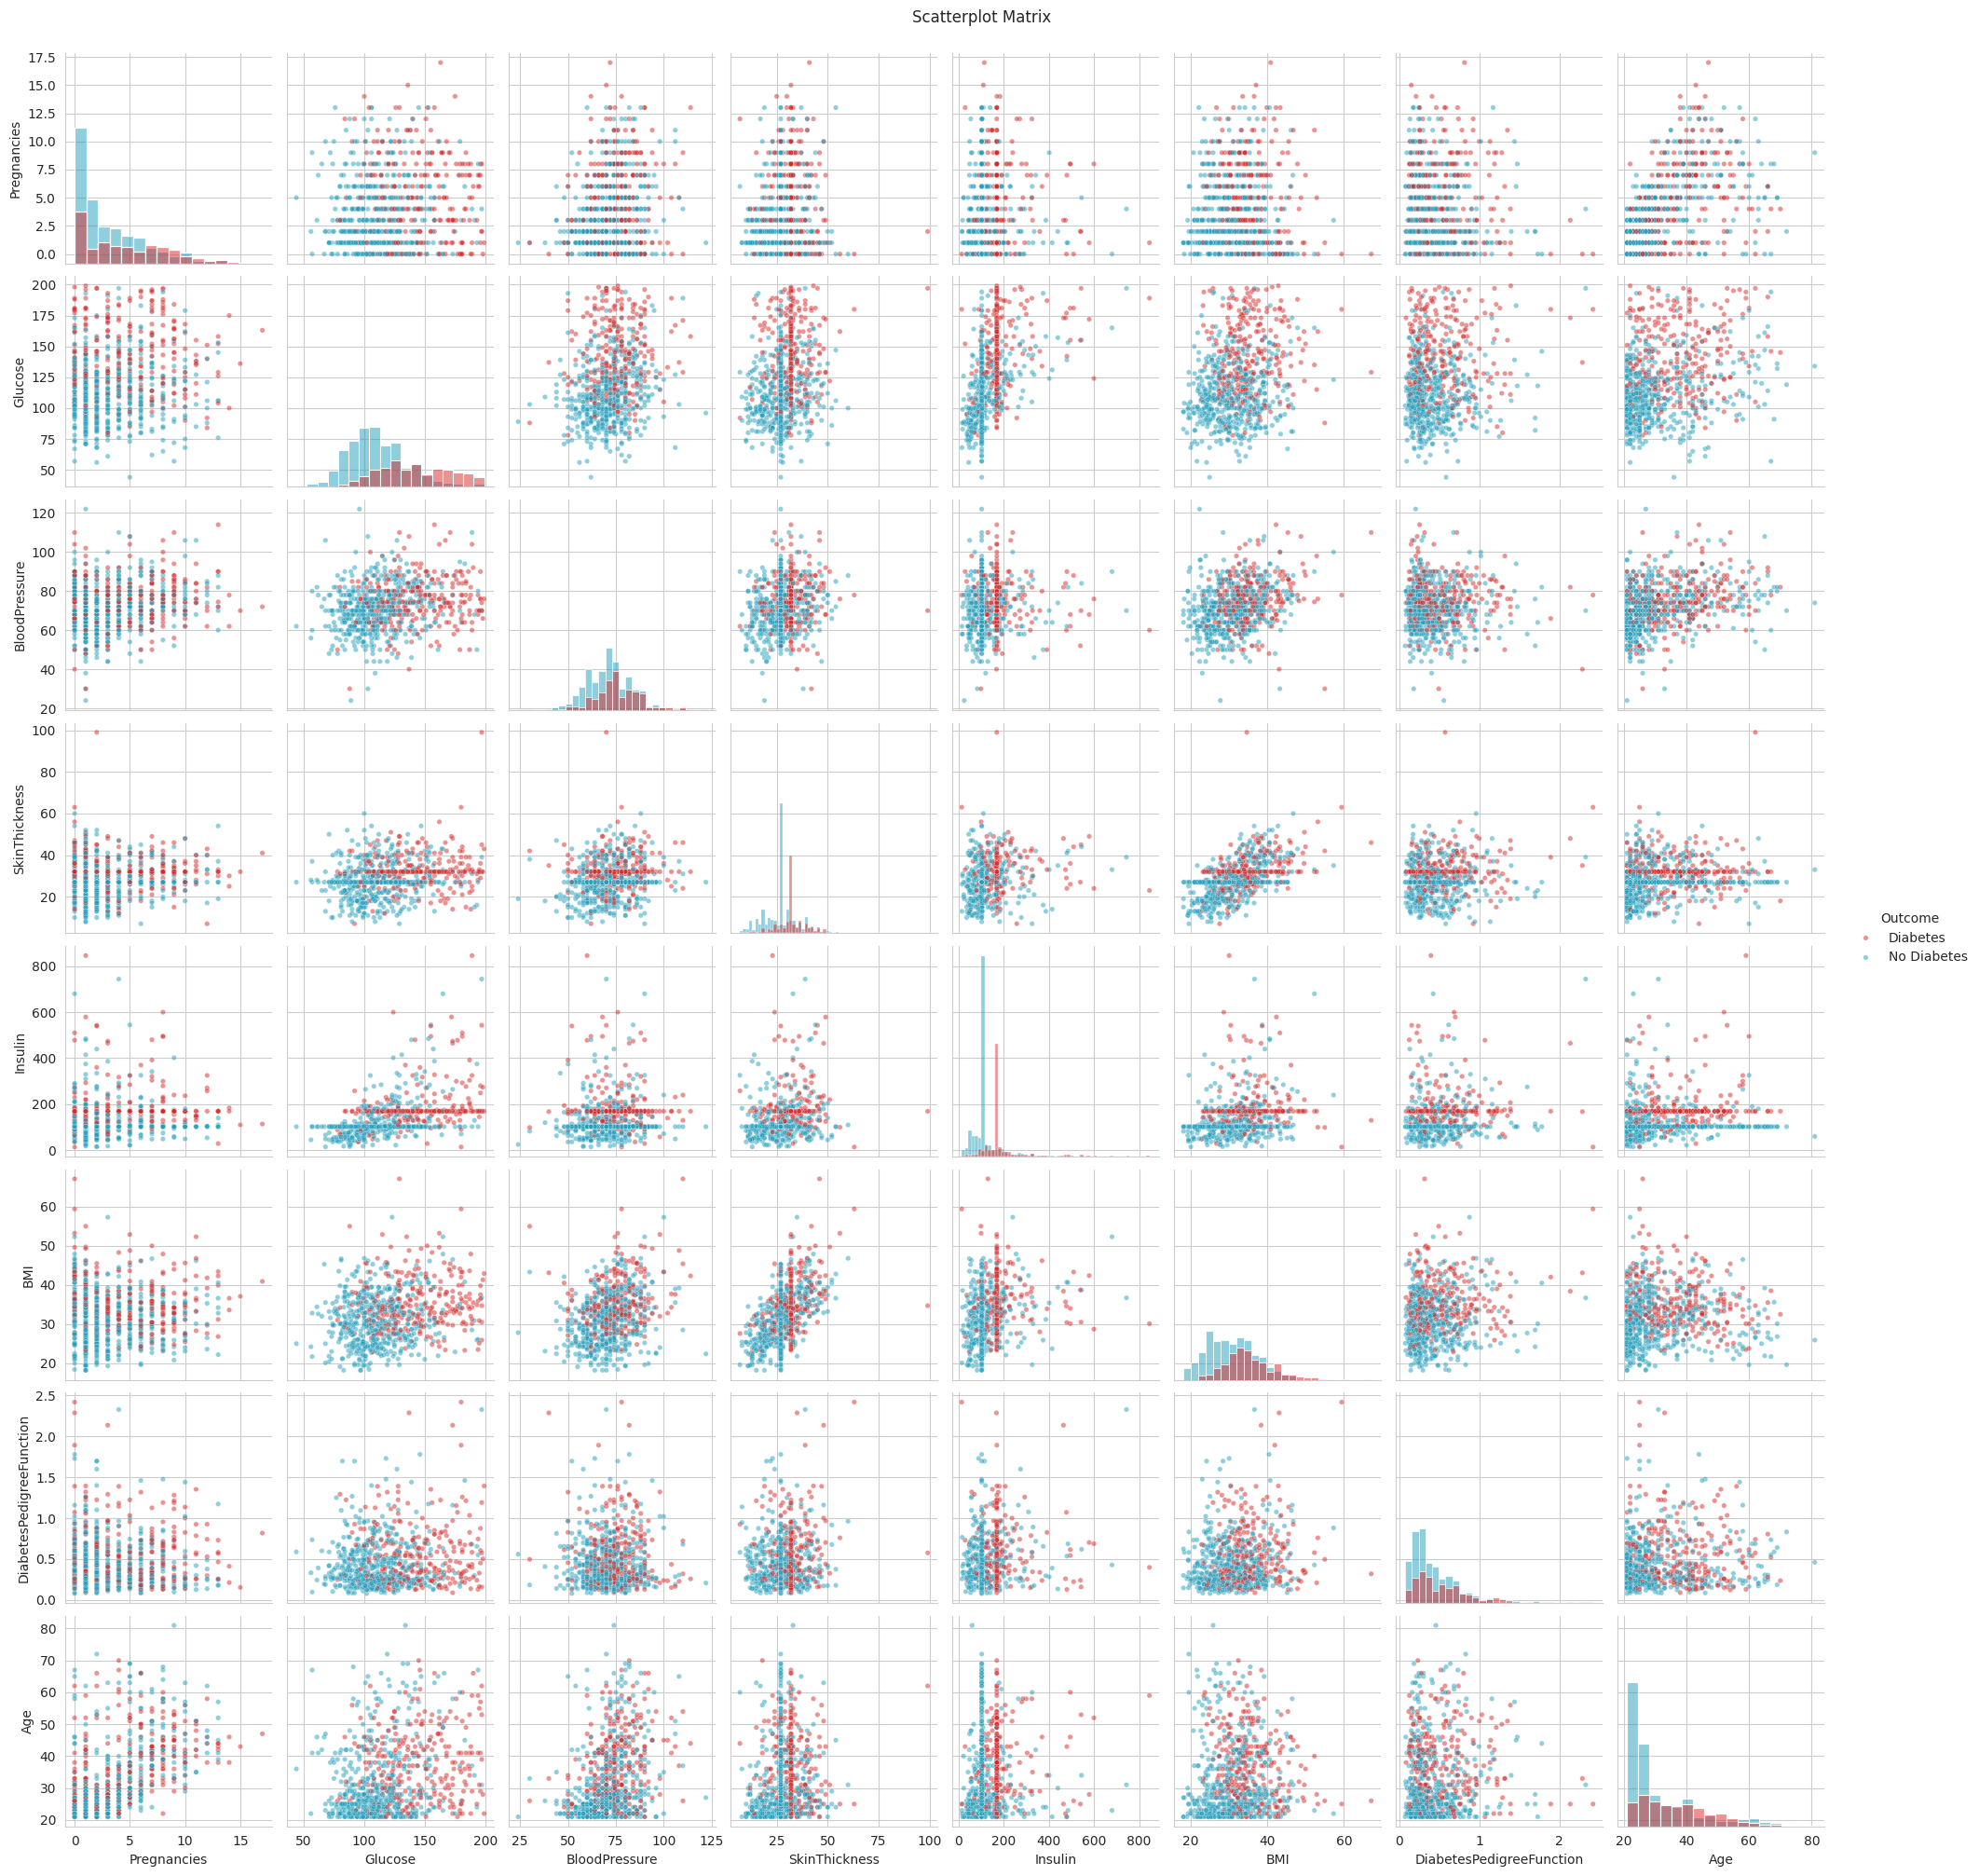

In [42]:
sns.pairplot(df2, vars=num_vars_py, hue="Outcome", palette=out_colors,
             diag_kind="hist", plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle("Scatterplot Matrix", y=1.01)
plt.show()

## 15. KNN Classification and Hierarchical Clustering — Setup

- **K-Nearest Neighbours**: classify `Outcome` from the numeric features.
- **Hierarchical (agglomerative) clustering**: cluster the observations using
  **average**, **single (minimum)** and **complete (maximum)** linkage, and compare
  the resulting clusters to the true `Outcome` labels.

Features are standardized (mean 0, sd 1) first, since both KNN and clustering are distance-based.

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, adjusted_rand_score)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

X = df_p2[num_vars_py].values
y = df_p2["Outcome"].values          # 0 / 1

scaler_p3 = StandardScaler()
X_scaled = scaler_p3.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)
print("Train / test shapes:", X_train.shape, X_test.shape)

Train / test shapes: (572, 8) (191, 8)


## KNN — Choosing k

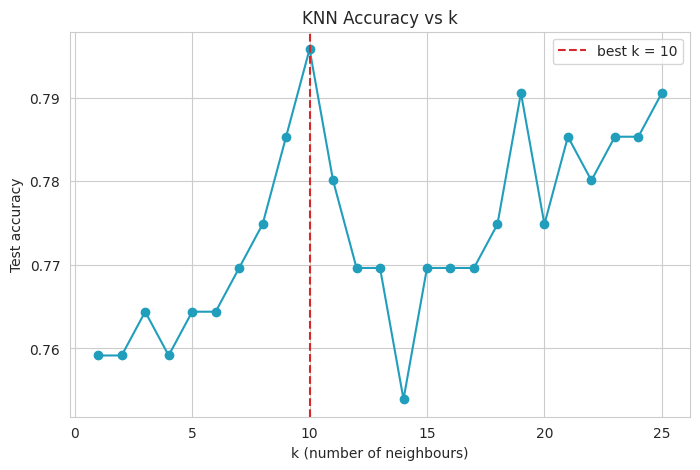

Best k on this split: 10 (accuracy = 0.7958)


In [44]:
k_range = range(1, 26)
accs = []
for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, knn_k.predict(X_test)))

best_k = k_range[int(np.argmax(accs))]
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), accs, marker="o", color="#219ebc")
plt.axvline(best_k, color="#d62828", linestyle="--", label=f"best k = {best_k}")
plt.xlabel("k (number of neighbours)"); plt.ylabel("Test accuracy")
plt.title("KNN Accuracy vs k"); plt.legend(); plt.show()

print(f"Best k on this split: {best_k} (accuracy = {max(accs):.4f})")

## KNN — Final Model and Evaluation

Accuracy: 0.7958

Classification report:
              precision    recall  f1-score   support

 No Diabetes       0.81      0.90      0.85       124
    Diabetes       0.76      0.61      0.68        67

    accuracy                           0.80       191
   macro avg       0.78      0.75      0.76       191
weighted avg       0.79      0.80      0.79       191



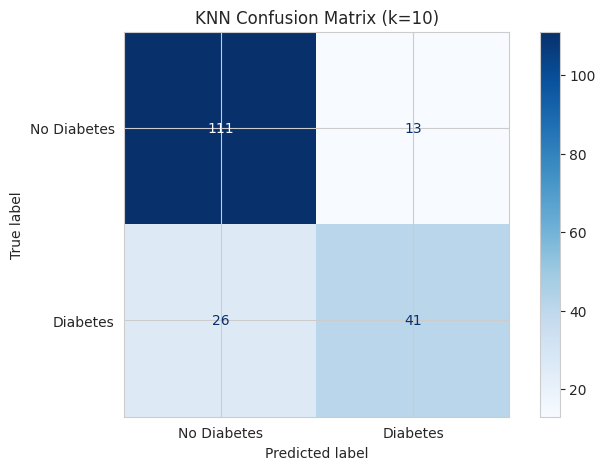

In [45]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"KNN Confusion Matrix (k={best_k})")
plt.show()

## 16. Hierarchical Clustering — Average, Single (Minimum) and Complete (Maximum) Linkage

Agglomerative clustering starts with every point as its own cluster and repeatedly
merges the two closest clusters. The **linkage** rule defines "closest cluster":

- **Average linkage** — mean distance between all pairs of points across the two clusters
- **Single (minimum) linkage** — distance between the two *closest* points across the two clusters
- **Complete (maximum) linkage** — distance between the two *farthest* points across the two clusters

Euclidean distance on the standardized features is used for all three.

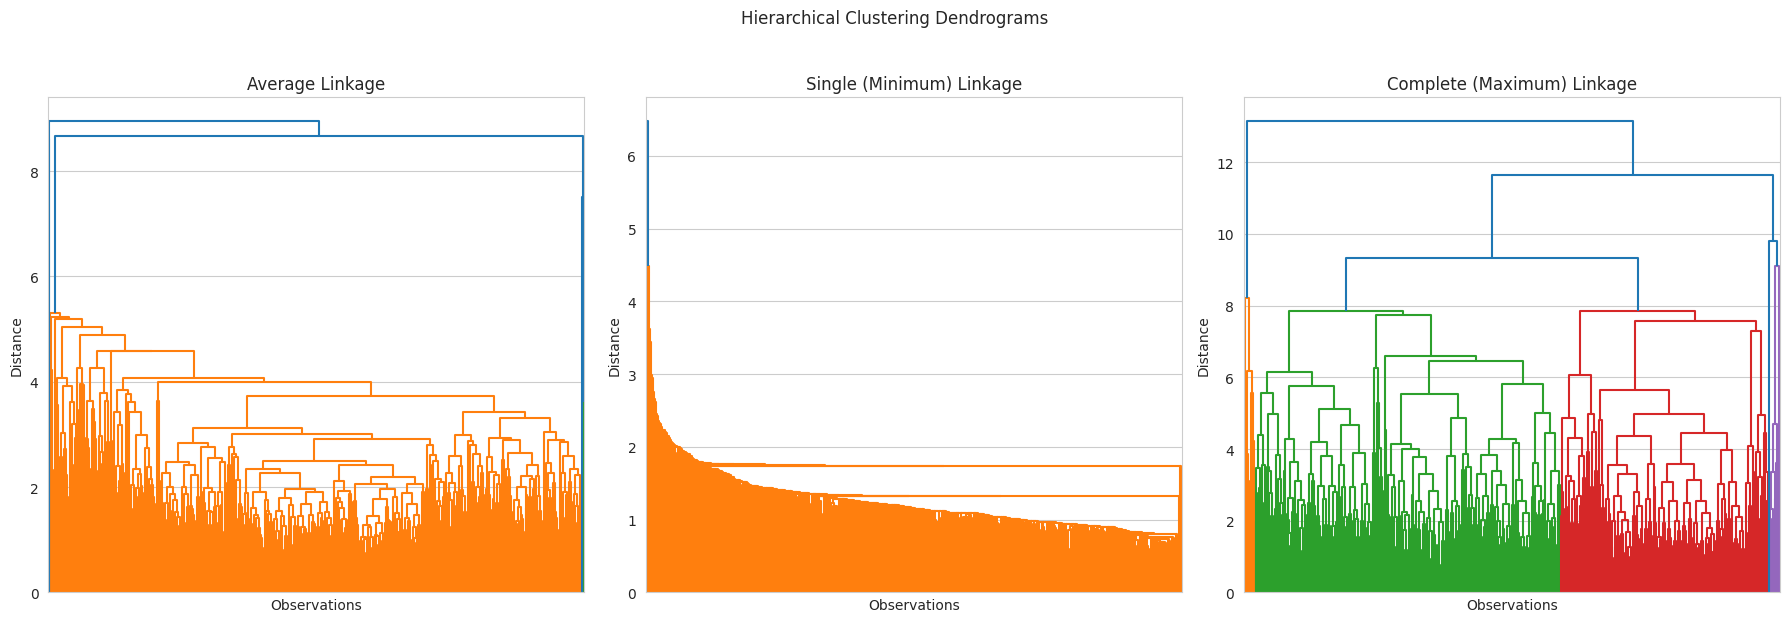

In [46]:
linkage_methods = {"Average": "average", "Single (Minimum)": "single", "Complete (Maximum)": "complete"}
linkage_matrices = {name: linkage(X_scaled, method=m) for name, m in linkage_methods.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, Z) in zip(axes, linkage_matrices.items()):
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(f"{name} Linkage")
    ax.set_xlabel("Observations"); ax.set_ylabel("Distance")
plt.suptitle("Hierarchical Clustering Dendrograms", y=1.03)
plt.tight_layout(); plt.show()

## Comparing the Three Linkages: Clusters vs Actual Outcome

Each dendrogram is cut into 2 clusters (to match the 2 `Outcome` classes) and compared
against the true labels with a contingency table and the Adjusted Rand Index (1.0 = perfect
agreement with `Outcome`, ~0 = no better than random).

In [47]:
for name, Z in linkage_matrices.items():
    clusters = fcluster(Z, t=2, criterion="maxclust")
    ari = adjusted_rand_score(y, clusters)
    ct = pd.crosstab(pd.Series(clusters, name="Cluster"),
                     pd.Series(df_p2["Outcome"].map({0: "No Diabetes", 1: "Diabetes"}).values, name="Outcome"))
    print(f"--- {name} linkage (Adjusted Rand Index = {ari:.4f}) ---")
    print(ct, "\n")

--- Average linkage (Adjusted Rand Index = 0.0045) ---
Outcome  Diabetes  No Diabetes
Cluster                       
1               2            0
2             265          496 

--- Single (Minimum) linkage (Adjusted Rand Index = 0.0022) ---
Outcome  Diabetes  No Diabetes
Cluster                       
1             266          496
2               1            0 

--- Complete (Maximum) linkage (Adjusted Rand Index = 0.0149) ---
Outcome  Diabetes  No Diabetes
Cluster                       
1              10            6
2             257          490 

